# House prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"C:\Users\Mayur\OneDrive\Documents\Mumbai House Price Prediction\mumbai_house_price_pred.csv")
df.head()

,Building_Name,Carpet_Area,BHK,Floor_Number,Location,Furnished,Type,Bathrooms,Parking,Lift,Railway_Station-KM,Price,Available_for_Rent,Rented_Price
0,Urban Residency 1,504,4.0,24,Kandivali East,Semi-Furnished,Flat,1,Yes,Yes,4,1483239,No,0
1,Sunrise Apartments 2,972,1.0,12,Malad East,NaN,Flat,1,No,Yes,0,3778621,Yes,18514
2,Urban View 3,1148,4.0,8,Seawoods,Semi-Furnished,Flat,2,Yes,Yes,2,2554571,No,0
3,Sai Chawl,3260,NaN,1,Ghatkopar West,NaN,Chawl,0,Yes,No,2,1934681,No,0
4,Sai Apartments 5,1975,NaN,18,Kandivali East,Unfurnished,Bungalow,2,Yes,Yes,1,1056664,Yes,28289


In [3]:
print("Shape of the Dataset :",df.shape)

Shape of the Dataset : (2500, 14)


# Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Building_Name       2460 non-null   object 
 1   Carpet_Area         2500 non-null   int64  
 2   BHK                 2430 non-null   float64
 3   Floor_Number        2500 non-null   int64  
 4   Location            2452 non-null   object 
 5   Furnished           2458 non-null   object 
 6   Type                2500 non-null   object 
 7   Bathrooms           2500 non-null   int64  
 8   Parking             2456 non-null   object 
 9   Lift                2446 non-null   object 
 10  Railway_Station-KM  2500 non-null   int64  
 11  Price               2500 non-null   int64  
 12  Available_for_Rent  2447 non-null   object 
 13  Rented_Price        2500 non-null   int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 273.6+ KB


In [5]:
df.describe(include="all")

,Building_Name,Carpet_Area,BHK,Floor_Number,Location,Furnished,Type,Bathrooms,Parking,Lift,Railway_Station-KM,Price,Available_for_Rent,Rented_Price
count,2460,2500.000000,2430.000000,2500.000000,2452,2458,2500,2500.000000,2456,2446,2500.000000,2.500000e+03,2447,2500.000000
unique,434,NaN,NaN,NaN,38,3,3,NaN,2,2,NaN,NaN,2,NaN
top,Sai Chawl,NaN,NaN,NaN,Bandra East,Semi-Furnished,Bungalow,NaN,No,Yes,NaN,NaN,No,NaN
freq,836,NaN,NaN,NaN,87,838,854,NaN,1234,1224,NaN,NaN,1225,NaN
mean,NaN,1898.932000,2.599177,11.236400,NaN,NaN,NaN,2.386000,NaN,NaN,2.206000,2.709316e+06,NaN,11960.450400
std,NaN,911.362458,1.209540,7.527601,NaN,NaN,NaN,1.166854,NaN,NaN,1.343535,1.342910e+06,NaN,13815.885758
min,NaN,0.000000,1.000000,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000e+00,NaN,0.000000
25%,NaN,1127.750000,2.000000,4.000000,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,1.538375e+06,NaN,0.000000
50%,NaN,1865.000000,3.000000,11.000000,NaN,NaN,NaN,2.000000,NaN,NaN,2.000000,2.758497e+06,NaN,0.000000
75%,NaN,2681.000000,4.000000,18.000000,NaN,NaN,NaN,3.000000,NaN,NaN,3.000000,3.830952e+06,NaN,24590.000000


In [6]:
df.isnull().sum()

Building_Name         40
Carpet_Area            0
BHK                   70
Floor_Number           0
Location              48
Furnished             42
Type                   0
Bathrooms              0
Parking               44
Lift                  54
Railway_Station-KM     0
Price                  0
Available_for_Rent    53
Rented_Price           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['BHK'].fillna(df['BHK'].mean(),inplace=True)
df['Bathrooms'].fillna(df['Bathrooms'].median(),inplace=True)

df['Furnished'].fillna(df['Furnished'].mode()[0],inplace=True)
df['Type'].fillna(df['Type'].mode()[0],inplace=True)

C:\Users\Mayur\AppData\Local\Temp\ipykernel_23072\2674463766.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['BHK'].fillna(df['BHK'].mean(),inplace=True)
C:\Users\Mayur\AppData\Local\Temp\ipykernel_23072\2674463766.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [9]:
df.head(10)

,Building_Name,Carpet_Area,BHK,Floor_Number,Location,Furnished,Type,Bathrooms,Parking,Lift,Railway_Station-KM,Price,Available_for_Rent,Rented_Price
0,Urban Residency 1,504,4.000000,24,Kandivali East,Semi-Furnished,Flat,1,Yes,Yes,4,1483239,No,0
1,Sunrise Apartments 2,972,1.000000,12,Malad East,Semi-Furnished,Flat,1,No,Yes,0,3778621,Yes,18514
2,Urban View 3,1148,4.000000,8,Seawoods,Semi-Furnished,Flat,2,Yes,Yes,2,2554571,No,0
3,Sai Chawl,3260,2.599177,1,Ghatkopar West,Semi-Furnished,Chawl,0,Yes,No,2,1934681,No,0
4,Sai Apartments 5,1975,2.599177,18,Kandivali East,Unfurnished,Bungalow,2,Yes,Yes,1,1056664,Yes,28289
5,Galaxy Plaza 6,2421,2.599177,1,Chembur,Unfurnished,Bungalow,2,No,No,1,1127155,NaN,0
6,Urban Apartments 7,1888,2.599177,1,Ghatkopar East,Furnished,Bungalow,3,Yes,No,2,2155196,Yes,36026
7,NaN,1652,4.000000,1,Kurla East,Unfurnished,Bungalow,2,No,No,3,1980436,No,0
8,Sai Chawl,1377,5.000000,17,Kurla West,Furnished,Chawl,3,NaN,NaN,3,1055765,No,0
9,Sunrise View 10,1536,1.000000,1,NaN,Semi-Furnished,Bungalow,1,No,No,2,2271395,Yes,18091


In [10]:
df1 = df.dropna()

In [11]:
df1.shape

(2299, 14)

In [12]:
df1.isnull().sum()

Building_Name         0
Carpet_Area           0
BHK                   0
Floor_Number          0
Location              0
Furnished             0
Type                  0
Bathrooms             0
Parking               0
Lift                  0
Railway_Station-KM    0
Price                 0
Available_for_Rent    0
Rented_Price          0
dtype: int64

In [13]:
df1["Type"].unique()

array(['Flat', 'Chawl', 'Bungalow'], dtype=object)

In [14]:
df1.loc[2]

Building_Name           Urban View 3
Carpet_Area                     1148
BHK                              4.0
Floor_Number                       8
Location                    Seawoods
Furnished             Semi-Furnished
Type                            Flat
Bathrooms                          2
Parking                          Yes
Lift                             Yes
Railway_Station-KM                 2
Price                        2554571
Available_for_Rent                No
Rented_Price                       0
Name: 2, dtype: object

In [15]:
df1.nunique()

Building_Name          430
Carpet_Area           1592
BHK                      6
Floor_Number            26
Location                38
Furnished                3
Type                     3
Bathrooms                6
Parking                  2
Lift                     2
Railway_Station-KM       5
Price                 2266
Available_for_Rent       2
Rented_Price          1134
dtype: int64

In [16]:
df1.groupby("Type")["Type"].agg("count")

Type
Bungalow    775
Chawl       785
Flat        739
Name: Type, dtype: int64

In [17]:
df1["Location"].value_counts().sort_values(ascending = False).head(5)

Location
Bandra East       83
Kharghar          72
Lower Parel       71
Chembur           70
Santacruz East    69
Name: count, dtype: int64

In [18]:
df['BHK'] = df['BHK'].astype(int)
df['Bathrooms'] = df['Bathrooms'].astype(int)

# Data Visualization

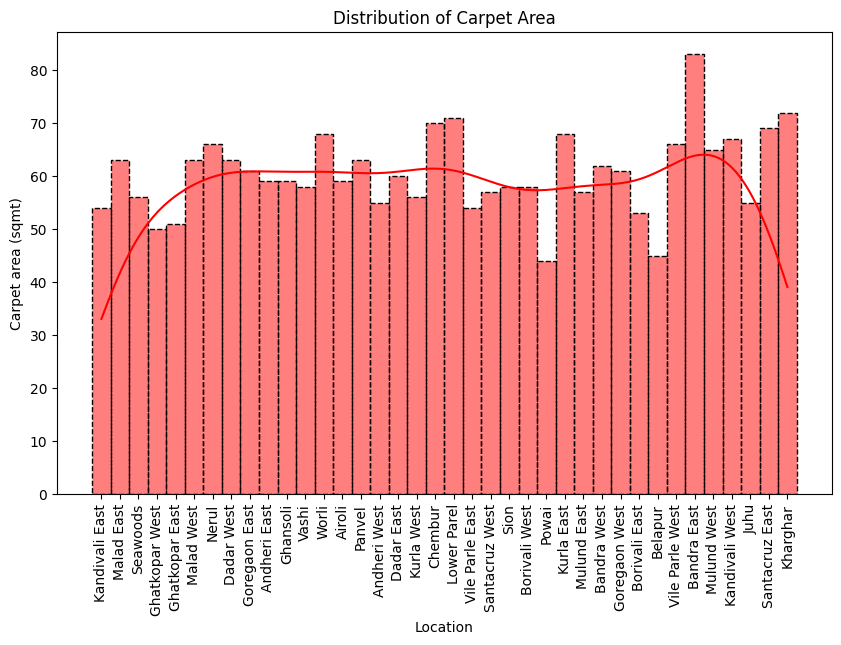

In [19]:
# Histogram
plt.figure(figsize = (10,6))
sns.histplot(df1["Location"], bins = 30, kde = True , color='red', edgecolor ="black", linestyle ="--", alpha = 0.5)
plt.xticks(rotation = 90)
plt.title("Distribution of Carpet Area")
plt.xlabel("Location")
plt.ylabel("Carpet area (sqmt)")
plt.show()


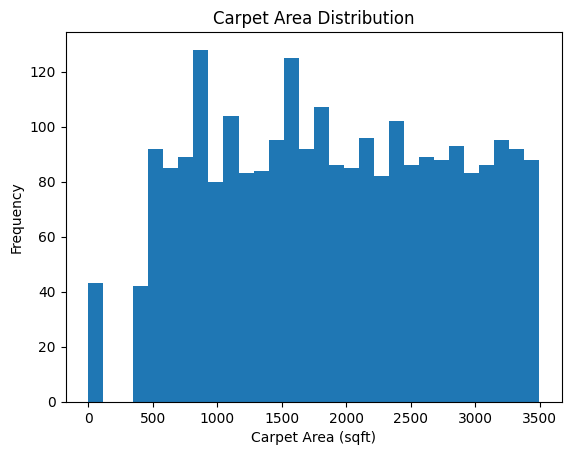

In [20]:
plt.figure()
plt.hist(df["Carpet_Area"], bins = 30)
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Frequency")
plt.title("Carpet Area Distribution")
plt.show()


C:\Users\Mayur\AppData\Local\Temp\ipykernel_23072\1464255593.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = "Location", data = df1, palette = "coolwarm", order = df1["Location"].value_counts().index, legend = True)


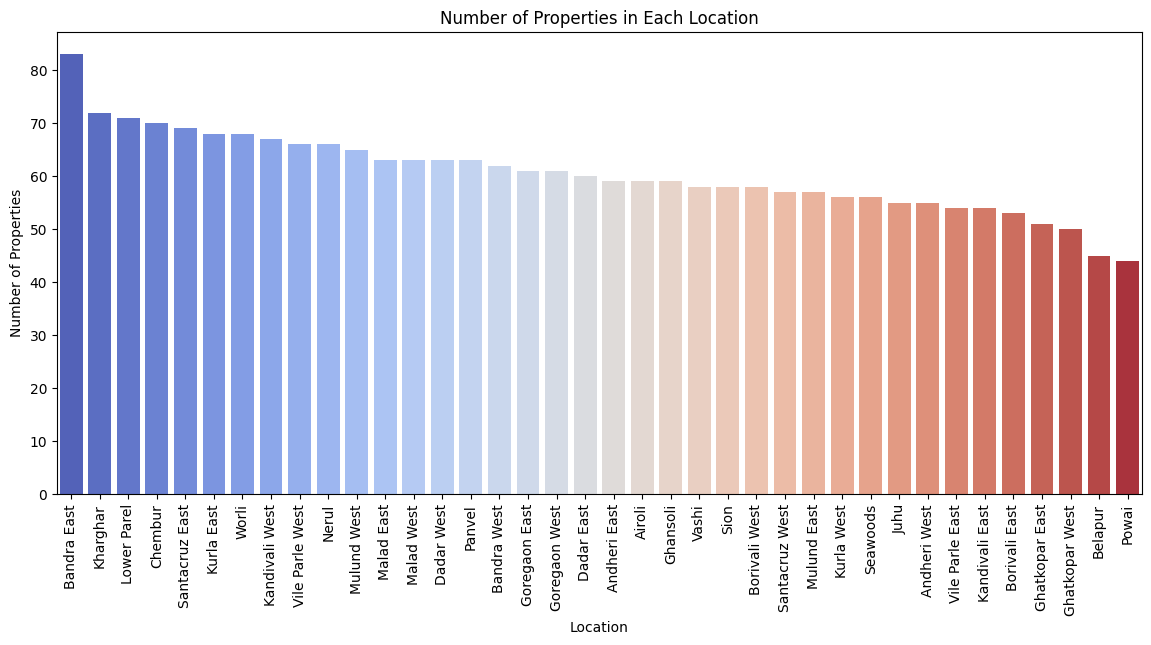

In [21]:
plt.figure(figsize = (14,6))
sns.countplot(x = "Location", data = df1, palette = "coolwarm", order = df1["Location"].value_counts().index, legend = True)
plt.xticks(rotation = 90) 
plt.title("Number of Properties in Each Location")
plt.xlabel("Location")
plt.ylabel("Number of Properties")
plt.show()


C:\Users\Mayur\AppData\Local\Temp\ipykernel_23072\762238180.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data  = rent_data, x = 'Location',palette = "coolwarm", order = rent_data['Location'].value_counts().index)


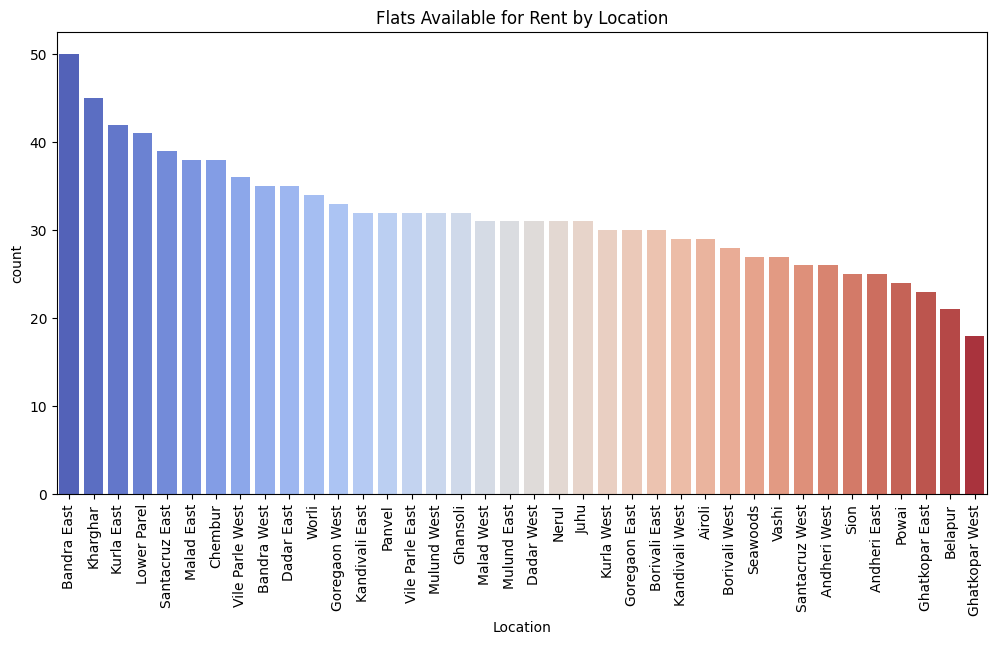

In [22]:
rent_data = df[df['Available_for_Rent'] == 'Yes']

plt.figure(figsize = (12,6))
sns.countplot(data  = rent_data, x = 'Location',palette = "coolwarm", order = rent_data['Location'].value_counts().index)
plt.xticks(rotation = 90)
plt.title("Flats Available for Rent by Location")
plt.show()

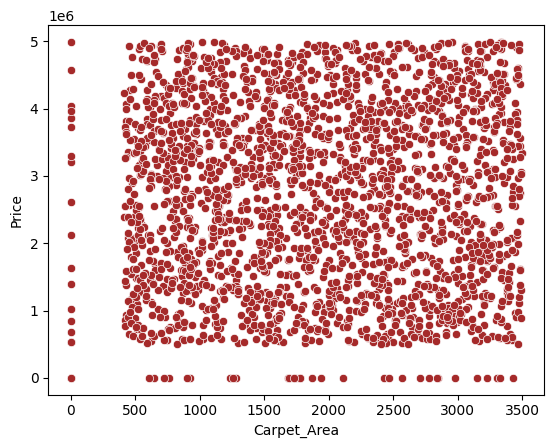

In [23]:
sns.scatterplot(x = 'Carpet_Area', y = 'Price', data = df1, color = "brown")
plt.show()

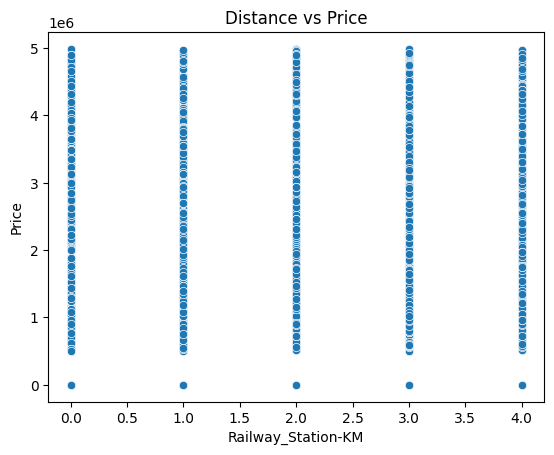

In [24]:
sns.scatterplot(
    x = 'Railway_Station-KM', y = 'Price', data = df1)
plt.title("Distance vs Price")
plt.show()

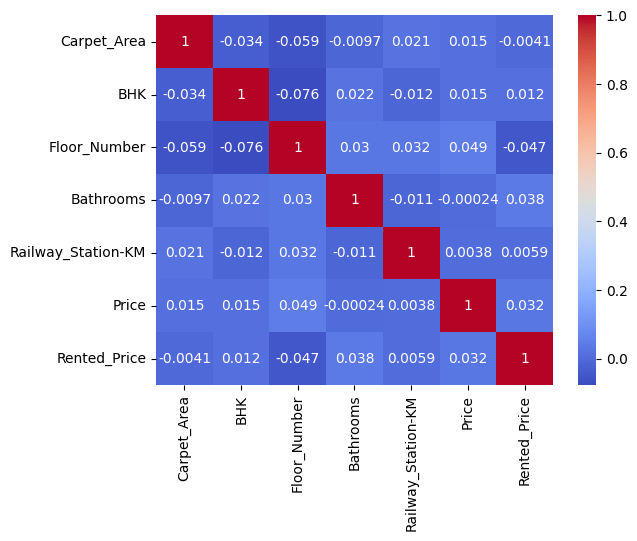

In [25]:
heatmap = df1.select_dtypes(include = ['number'])
sns.heatmap(heatmap.corr(), annot = True, cmap = 'coolwarm')
plt.show()

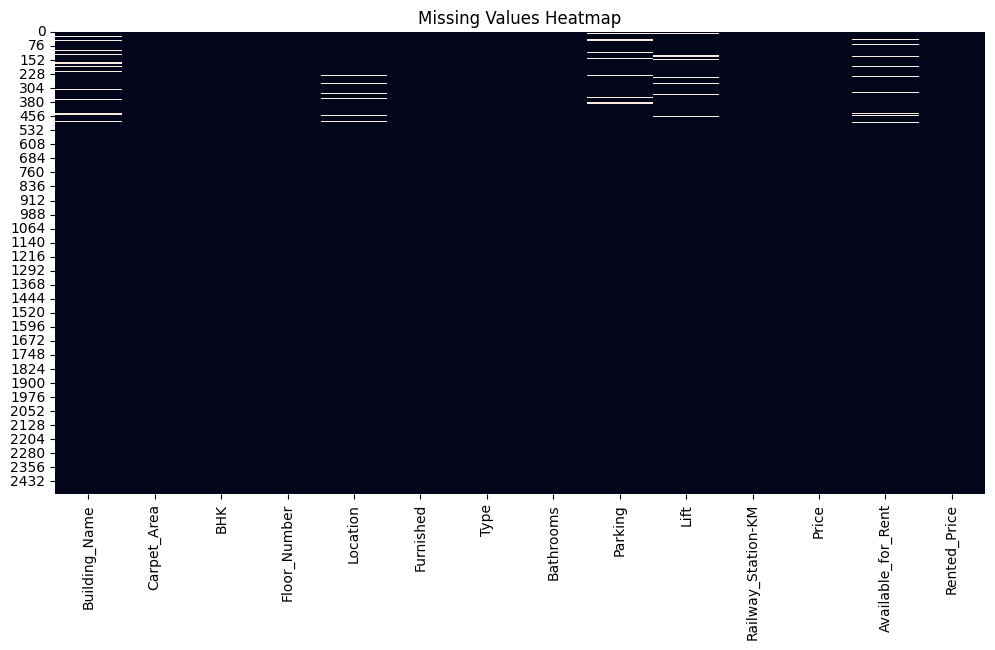

In [26]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [27]:
#Average price by bhk
df1.groupby('BHK')['Price'].mean().head()

BHK
1.000000    2.642079e+06
2.000000    2.757877e+06
2.599177    2.351010e+06
3.000000    2.768961e+06
4.000000    2.748079e+06
Name: Price, dtype: float64

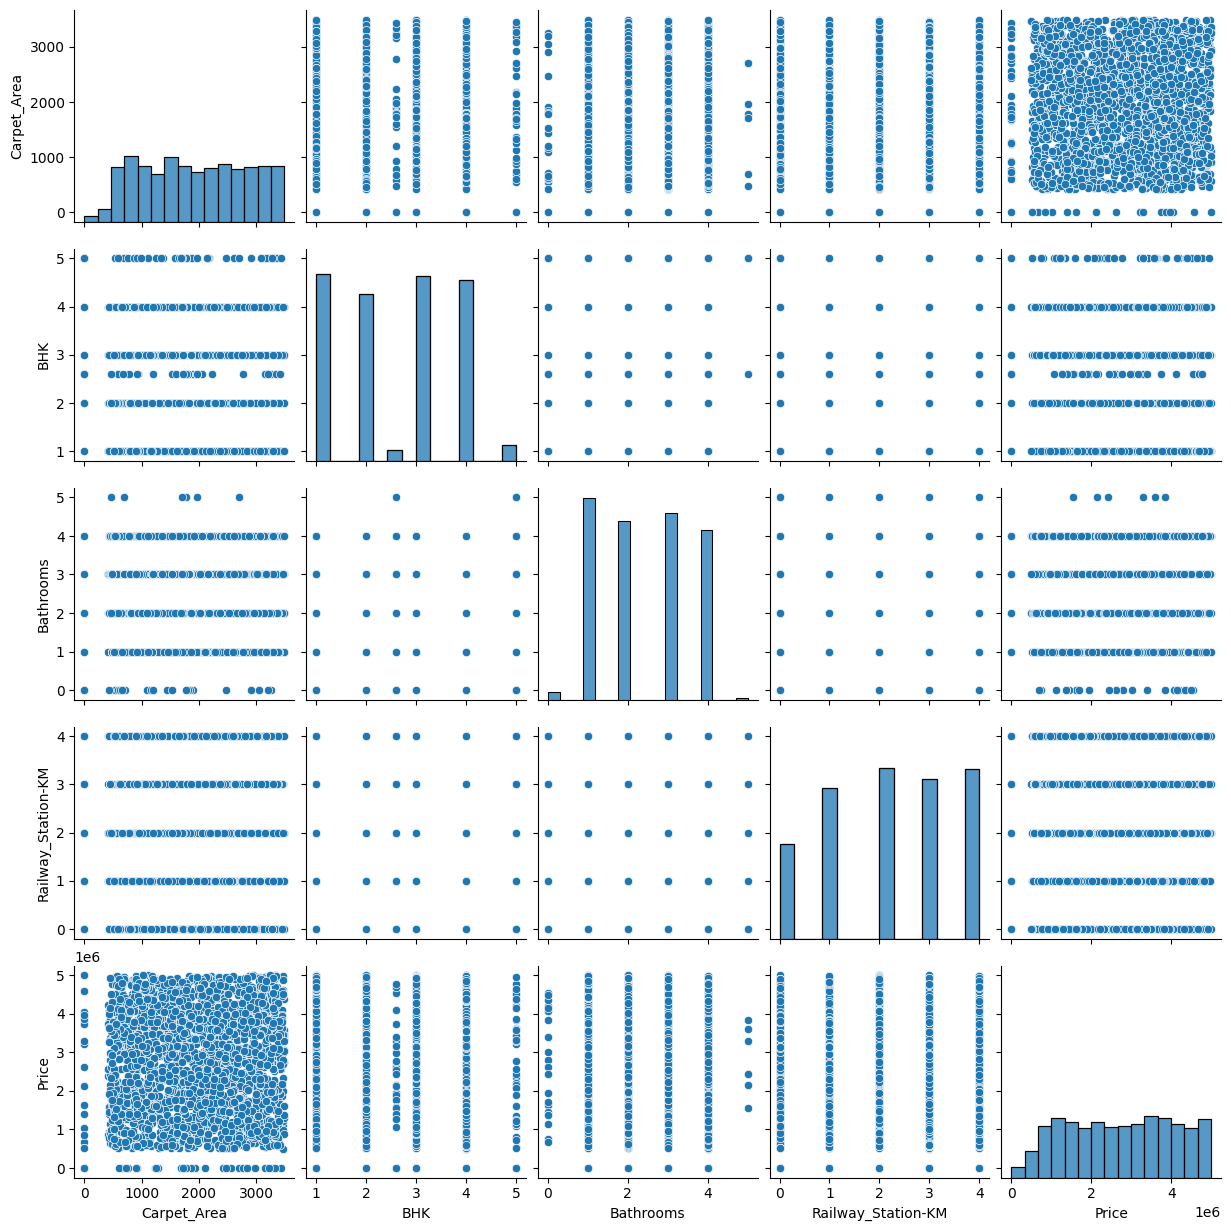

In [28]:
sns.pairplot( df1[['Carpet_Area', 'BHK', 'Bathrooms', 'Railway_Station-KM', 'Price']])
plt.show()

In [29]:
df['Price_per_sqft'] = df1['Price'] / df1['Carpet_Area']

In [30]:
# Drop non-useful column
df1_model = df1.drop(['Building_Name'], axis=1, errors='ignore')

# Drop any remaining rows with NaN
df1_model.dropna(inplace=True)
df1_model.shape

# Convert categorical variables into dummy
df1_model = pd.get_dummies(df1_model, drop_first=True)

# x and y
X = df1_model.drop('Price', axis=1)
y = df1_model['Price']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2299, 50)
Target Shape: (2299,)


# Outlier

In [31]:
df1[df1.Carpet_Area/df1.BHK > 500].head()

,Building_Name,Carpet_Area,BHK,Floor_Number,Location,Furnished,Type,Bathrooms,Parking,Lift,Railway_Station-KM,Price,Available_for_Rent,Rented_Price
1,Sunrise Apartments 2,972,1.000000,12,Malad East,Semi-Furnished,Flat,1,No,Yes,0,3778621,Yes,18514
3,Sai Chawl,3260,2.599177,1,Ghatkopar West,Semi-Furnished,Chawl,0,Yes,No,2,1934681,No,0
4,Sai Apartments 5,1975,2.599177,18,Kandivali East,Unfurnished,Bungalow,2,Yes,Yes,1,1056664,Yes,28289
6,Urban Apartments 7,1888,2.599177,1,Ghatkopar East,Furnished,Bungalow,3,Yes,No,2,2155196,Yes,36026
10,Urban Villa 11,2047,4.000000,1,Malad West,Unfurnished,Flat,2,Yes,No,4,2675617,Yes,23826


In [32]:
df1.Carpet_Area.describe(include = "all")

count    2299.000000
mean     1925.066986
std       905.136376
min         0.000000
25%      1141.000000
50%      1904.000000
75%      2712.500000
max      3496.000000
Name: Carpet_Area, dtype: float64

# ML (Train, Test and Split)

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   # 80% training, 20% testing)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1839, 50)
Testing Data Shape: (460, 50)


# Model Building

In [34]:
df['BHK'] = df['BHK'].astype(int)
df['Bathrooms'] = df['Bathrooms'].astype(int)

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

R2 Score: -0.021730523427929915
MAE: 1173466.958575753


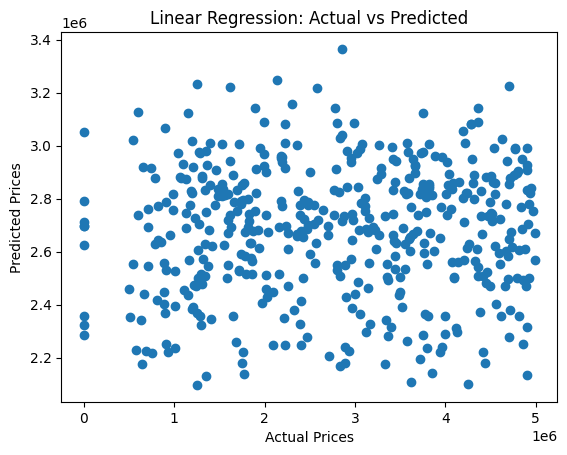

In [36]:
lr = LinearRegression()
combined_train = pd.concat([X_train, y_train], axis=1)
X_train_clean = combined_train[X_train.columns].replace([np.inf, -np.inf], np.nan).dropna()
y_train_clean = combined_train.loc[X_train_clean.index, y_train.name] # Align y_train_clean with cleaned X_train_clean
lr.fit(X_train_clean, y_train_clean);
combined_test = pd.concat([X_test, y_test], axis=1)

X_test_clean = combined_test[X_test.columns].replace([np.inf, -np.inf], np.nan).dropna()
y_test_clean = combined_test.loc[X_test_clean.index, y_test.name] # Align y_test_clean with cleaned X_test_clean
y_pred = lr.predict(X_test_clean)

r2_lr = r2_score(y_test_clean, y_pred)
mae_lr = mean_absolute_error(y_test_clean, y_pred)
print("R2 Score:", r2_lr)
print("MAE:", mae_lr)

plt.figure()
plt.scatter(y_test_clean, y_pred) # Use y_test_clean for plotting consistency
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

Random Forest R2: -0.04192349857689748
Random Forest MAE: 1173292.7708913041


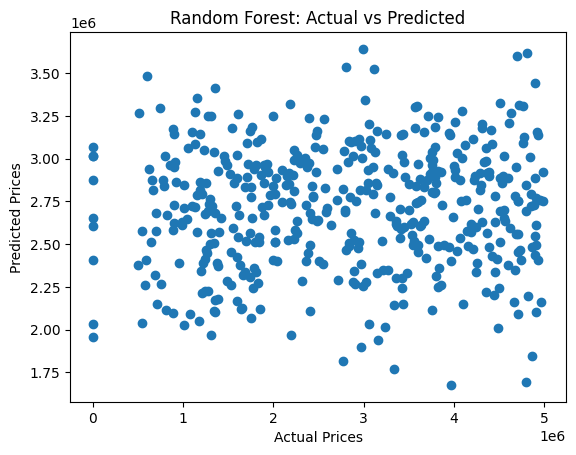

In [37]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest R2:", r2_rf)
print("Random Forest MAE:", mae_rf)

plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

Decision Tree R2: -0.9548758877851684
Decision Tree MAE: 1502828.4152173912


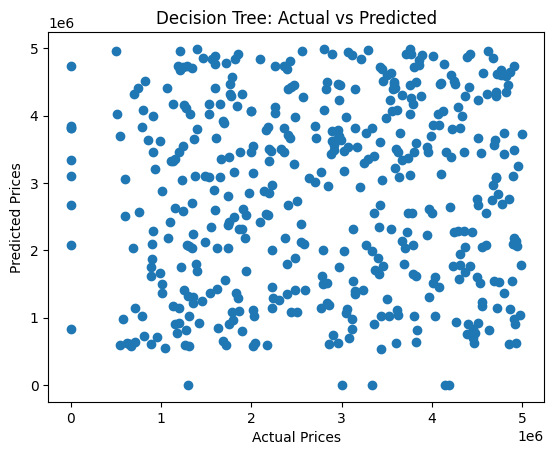

In [38]:

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)

print("Decision Tree R2:", r2_dt)
print("Decision Tree MAE:", mae_dt)

plt.figure()
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Decision Tree: Actual vs Predicted")
plt.show()

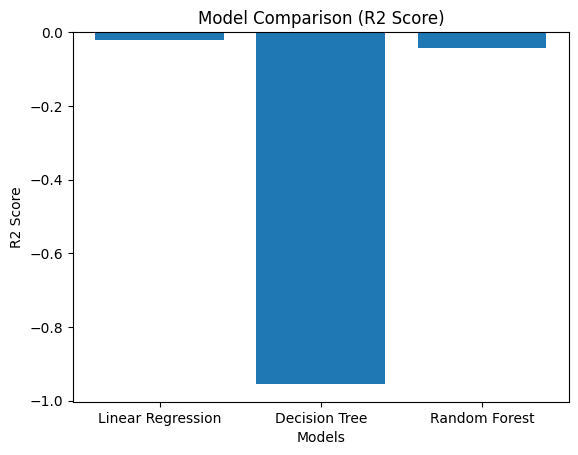

In [39]:
# #Model Comparison Graph (R² Score)
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [r2_lr, r2_dt, r2_rf]

plt.figure()
plt.bar(models, r2_scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison (R2 Score)")
plt.show()

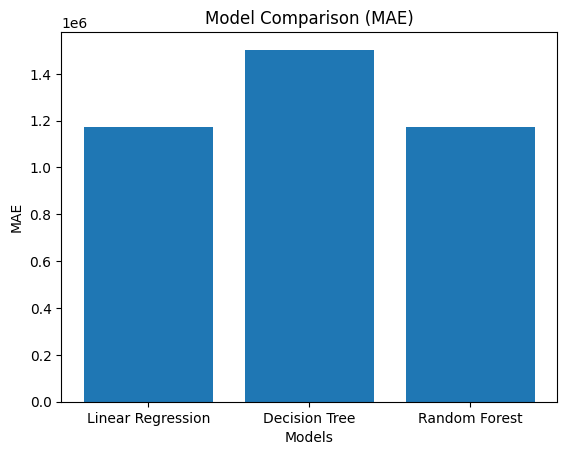

In [40]:

#Model Comparison Graph MAE
mae_scores = [mae_lr, mae_dt, mae_rf]

plt.figure()
plt.bar(models, mae_scores)
plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("Model Comparison (MAE)")
plt.show()

# Cleaning Data

In [41]:
column_data_types = df.dtypes
print(column_data_types)


Building_Name          object
Carpet_Area             int64
BHK                     int64
Floor_Number            int64
Location               object
Furnished              object
Type                   object
Bathrooms               int64
Parking                object
Lift                   object
Railway_Station-KM      int64
Price                   int64
Available_for_Rent     object
Rented_Price            int64
Price_per_sqft        float64
dtype: object


In [42]:
df2 = df1.drop(["Location","Building_Name","Furnished","Type","Parking","Lift","Available_for_Rent"], axis = "columns")
df2.head(3)

,Carpet_Area,BHK,Floor_Number,Bathrooms,Railway_Station-KM,Price,Rented_Price
0,504,4.0,24,1,4,1483239,0
1,972,1.0,12,1,0,3778621,18514
2,1148,4.0,8,2,2,2554571,0


In [43]:
df2.shape

(2299, 7)

In [44]:
display(df2.describe())

,Carpet_Area,BHK,Floor_Number,Bathrooms,Railway_Station-KM,Price,Rented_Price
count,2299.000000,2299.000000,2299.000000,2299.000000,2299.000000,2.299000e+03,2299.000000
mean,1925.066986,2.555186,11.631144,2.420183,2.211396,2.715405e+06,12294.827316
std,905.136376,1.163632,7.371446,1.147917,1.338533,1.329700e+06,13884.295600
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,1141.000000,2.000000,5.000000,1.000000,1.000000,1.558752e+06,0.000000
50%,1904.000000,3.000000,11.000000,2.000000,2.000000,2.754595e+06,8208.000000
75%,2712.500000,4.000000,18.000000,3.000000,3.000000,3.825164e+06,25168.500000
max,3496.000000,5.000000,25.000000,5.000000,4.000000,4.990559e+06,39989.000000


In [45]:
display(df2.corr())

,Carpet_Area,BHK,Floor_Number,Bathrooms,Railway_Station-KM,Price,Rented_Price
Carpet_Area,1.000000,-0.033655,-0.058711,-0.009712,0.021052,0.014996,-0.004098
BHK,-0.033655,1.000000,-0.076395,0.022313,-0.011630,0.014961,0.012264
Floor_Number,-0.058711,-0.076395,1.000000,0.030204,0.032383,0.048755,-0.047216
Bathrooms,-0.009712,0.022313,0.030204,1.000000,-0.011388,-0.000235,0.038218
Railway_Station-KM,0.021052,-0.011630,0.032383,-0.011388,1.000000,0.003771,0.005873
Price,0.014996,0.014961,0.048755,-0.000235,0.003771,1.000000,0.031621
Rented_Price,-0.004098,0.012264,-0.047216,0.038218,0.005873,0.031621,1.000000


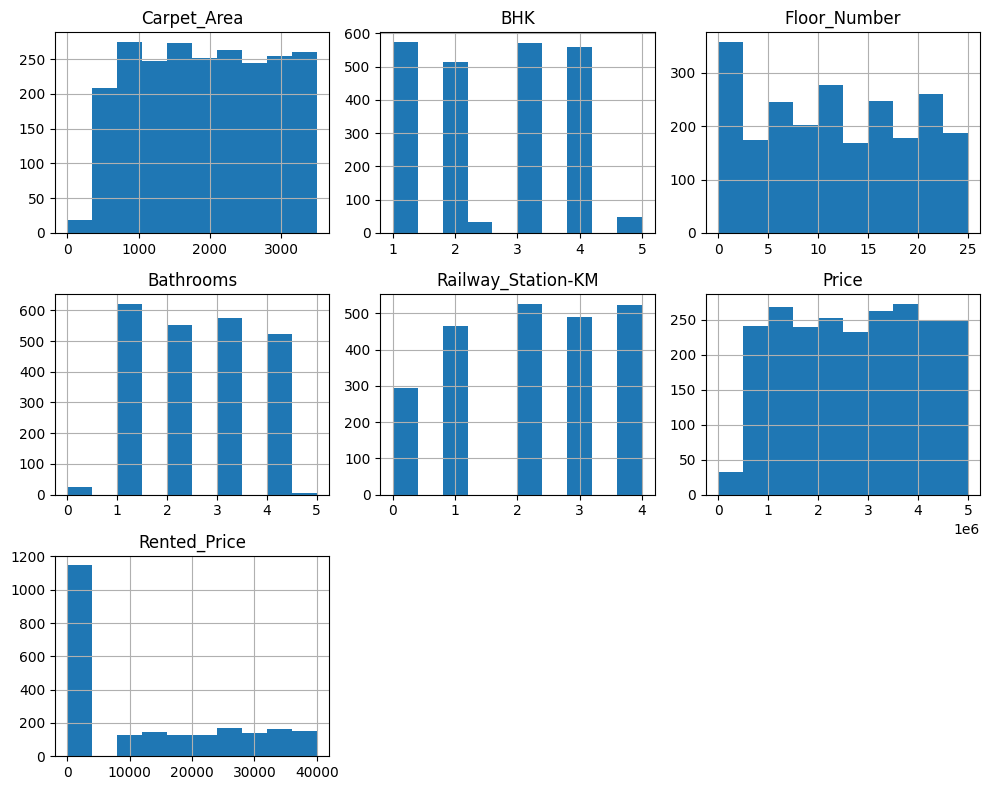

In [46]:
# Plot histograms for all numerical columns 
df2.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

In [47]:
# mean of each column 
print("Mean values for each column in df2:")
display(df2.mean())

# median of each column
print("\nMedian values for each column in df2:")
display(df2.median())

Mean values for each column in df2:


Carpet_Area           1.925067e+03
BHK                   2.555186e+00
Floor_Number          1.163114e+01
Bathrooms             2.420183e+00
Railway_Station-KM    2.211396e+00
Price                 2.715405e+06
Rented_Price          1.229483e+04
dtype: float64


Median values for each column in df2:


Carpet_Area              1904.0
BHK                         3.0
Floor_Number               11.0
Bathrooms                   2.0
Railway_Station-KM          2.0
Price                 2754595.0
Rented_Price             8208.0
dtype: float64

In [48]:
df2.to_csv(r"C:\Users\Mayur\OneDrive\Documents\Mumbai House Price Prediction\Mumbai_House_Price_Pred_cleaned.csv", index=False) #saving the cleaned data to a new csv file

# Predicting Price

In [49]:
df.columns

Index(['Building_Name', 'Carpet_Area', 'BHK', 'Floor_Number', 'Location',
       'Furnished', 'Type', 'Bathrooms', 'Parking', 'Lift',
       'Railway_Station-KM', 'Price', 'Available_for_Rent', 'Rented_Price',
       'Price_per_sqft'],
      dtype='object')

In [50]:
df2.columns

Index(['Carpet_Area', 'BHK', 'Floor_Number', 'Bathrooms', 'Railway_Station-KM',
       'Price', 'Rented_Price'],
      dtype='object')

In [51]:
np.where(X.columns == "Location_Nerul")[0][0]

np.int64(32)

In [52]:
def predict_price(Location,Carpet_Area,Bathrooms,BHK):
    loc_index = np.where(X.columns == Location)[0][0]

    x = np.zeros(len(X.columns))
    x[0] = Carpet_Area
    x[1] = Bathrooms
    x[2] = BHK
    if loc_index >= 0:
        x[loc_index] = 1
    return int(lr.predict([x])[0])

In [53]:
print("Price : ","Rs",predict_price("Location_Kandivali East",504,2,2))

Price :  Rs 2868134


c:\Users\Mayur\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [54]:
print("Price : ","Rs", predict_price("Location_Panvel",5554,2,2))

Price :  Rs 2639330


c:\Users\Mayur\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [55]:
print("Price : ","Rs",predict_price("Location_Kharghar",5754,12,2))

Price :  Rs 2940905


c:\Users\Mayur\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
